# yfinance Library Assignment  

In [5]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Function Specification: `download_historical_data`

Implement the function `download_historical_data` to fetch historical price data using Yahoo Finance as the data source. This function should be capable of fetching historical data for a specified stock symbol between given start and end dates. Additionally, it should support an optional parameter for the data timeframe with a default value of `'1d'` (daily).

---

### Function Specifications

**Parameters:**
- `symbol`: The ticker symbol of the stock (e.g., `'RELIANCE.NS'`).
- `start_date`: Start date for the data in `'YYYY-MM-DD'` format.
- `end_date`: End date for the data in `'YYYY-MM-DD'` format.
- `timeframe`: The frequency of the data (`'1d'`, `'1wk'`, `'1mo'`), default is `'1d'`.

**Return:**  
A pandas `DataFrame` containing the fetched data.


In [16]:
# Code Here 
def download_historical_data(ticker, start_date, end_date, timeframe='1d'):
    stock_data = yf.download(ticker, start=start_date, end=end_date, interval=timeframe)
    return stock_data

symbol = 'RELIANCE.NS'
data = download_historical_data(symbol, '2020-01-01', '2021-01-01')
result = pd.DataFrame(data)
result

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216248,680.008913,670.390593,675.956732,14004468
2020-01-02,683.660217,686.176147,673.284861,673.284861,17710316
2020-01-03,684.484131,686.487957,678.183188,682.636123,20984698
2020-01-06,668.609436,680.365168,667.050891,676.847384,24519177
2020-01-07,678.895752,683.304159,673.952948,676.402056,16683622
...,...,...,...,...,...
2020-12-24,900.048462,902.147175,878.271067,878.767526,20776988
2020-12-28,904.178284,910.813056,900.567511,905.712847,17221499


### Visualization

Create a function for plotting the stock closing prices. This function should accept parameters for the plot and its objective is to display the graph.
   


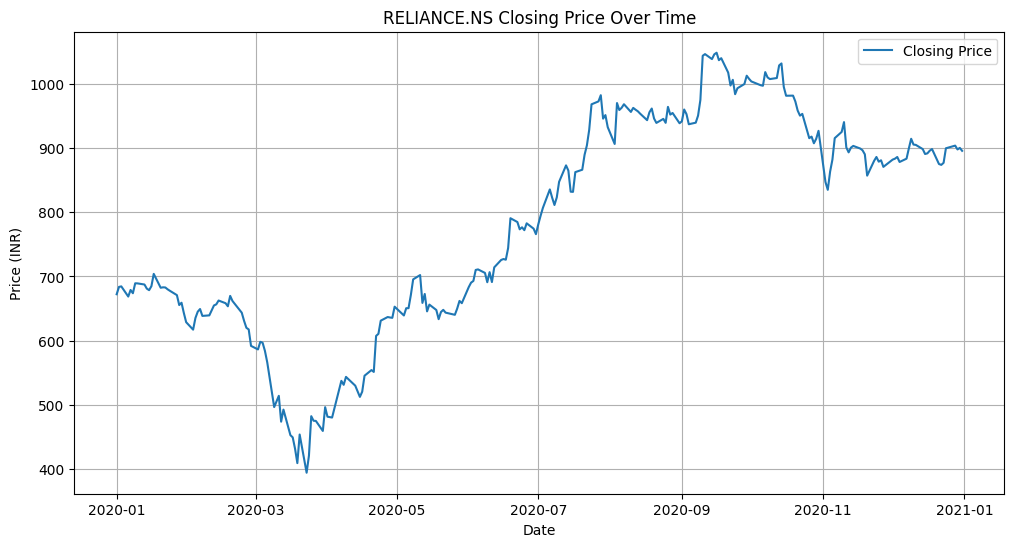

In [17]:
# Code here 
def plot_closing_price(stock_data, ticker):
    plt.figure(figsize=(12, 6))
    plt.plot(stock_data['Close'], label='Closing Price')
    plt.title(f'{ticker} Closing Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Price (INR)')
    plt.legend()
    plt.grid()
    plt.show()

plot_closing_price(data, symbol)

### Run the functions 

**Choose Stocks:**  
   - Select any three stocks of your choice.
   - Fetch their data for the time period from **2012 to 2022**.
   - Select daily time frame i.e. 1d.

**Plot the Data:**  
   1. Plot the data for each stock separately.  
   2. Combine the data and plot all three stocks on the **same graph** for comparison.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


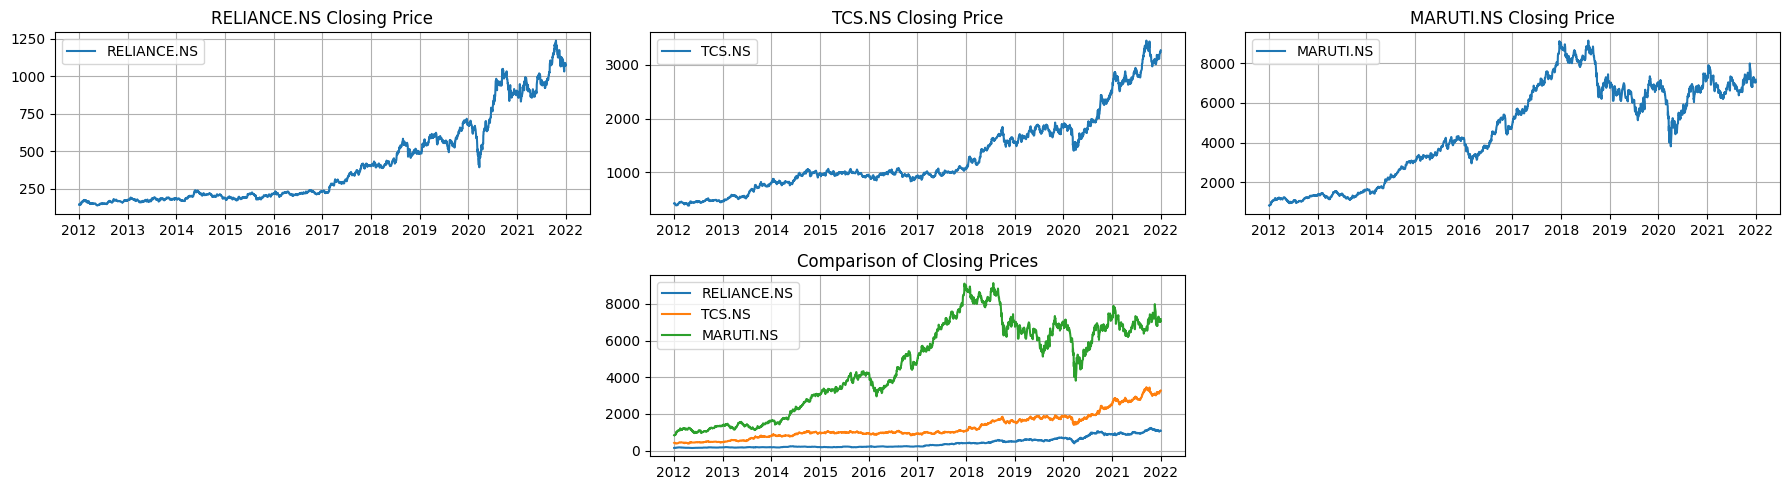

In [20]:
# Code here 
def stockanalysis12to22(stock1, stock2, stock3):
    stock_data1 = yf.download(stock1, start='2012-01-01', end='2022-01-01', interval='1d')
    stock_data2 = yf.download(stock2, start='2012-01-01', end='2022-01-01', interval='1d')
    stock_data3 = yf.download(stock3, start='2012-01-01', end='2022-01-01', interval='1d')
    
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 5))

    axes[0, 0].plot(stock_data1['Close'], label=stock1) ; axes[0, 0].set_title(f'{stock1} Closing Price') ; axes[0, 0].legend() ; axes[0, 0].grid()
    axes[0, 1].plot(stock_data2['Close'], label=stock2) ; axes[0, 1].set_title(f'{stock2} Closing Price') ; axes[0, 1].legend() ; axes[0, 1].grid()
    axes[0, 2].plot(stock_data3['Close'], label=stock3) ; axes[0, 2].set_title(f'{stock3} Closing Price') ; axes[0, 2].legend() ; axes[0, 2].grid()

    axes[1, 1].plot(stock_data1['Close'], label=stock1) ; axes[1, 1].plot(stock_data2['Close'], label=stock2) ; axes[1, 1].plot(stock_data3['Close'], label=stock3)
    axes[1, 1].set_title('Comparison of Closing Prices') ; axes[1, 1].legend() ; axes[1, 1].grid()

    axes[1, 0].axis('off') ; axes[1, 2].axis('off')
    plt.tight_layout()
    plt.show()

stockanalysis12to22('RELIANCE.NS', 'TCS.NS', 'MARUTI.NS')

### Technical Analysis 

**Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)**  
   - Plot the SMA and EMA of 5 days of each of the three stocks that you have selected.
   - SMA and EMA graph should be plotted on the same graph 
   - Hence you have to plot three graphs of each stock with SMA and EMA
    

[*********************100%***********************]  1 of 1 completed


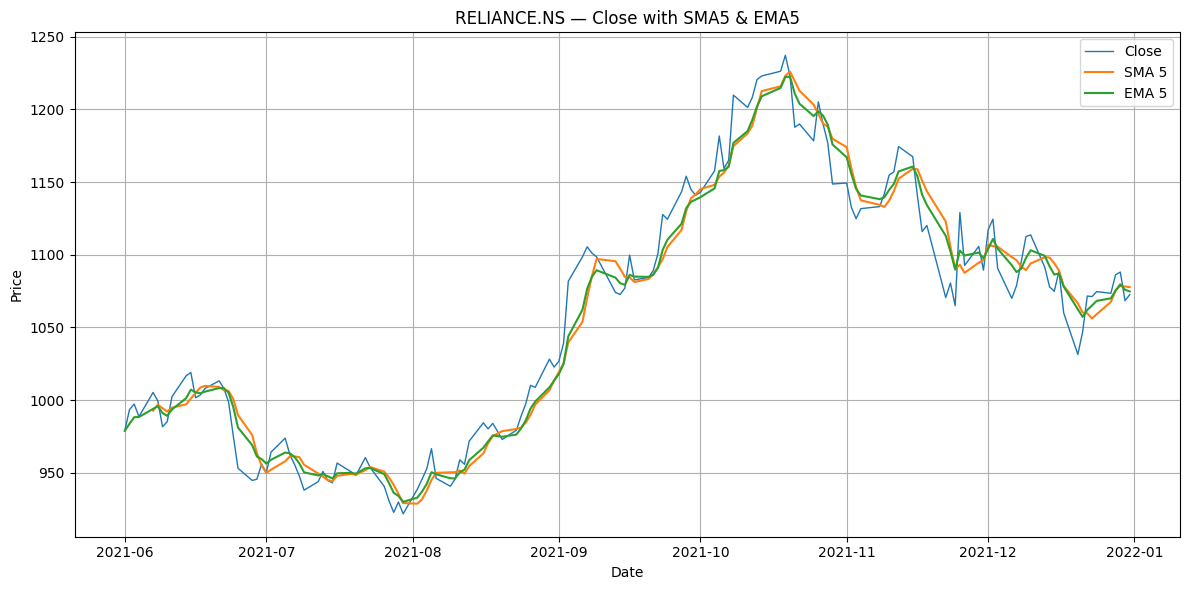

[*********************100%***********************]  1 of 1 completed


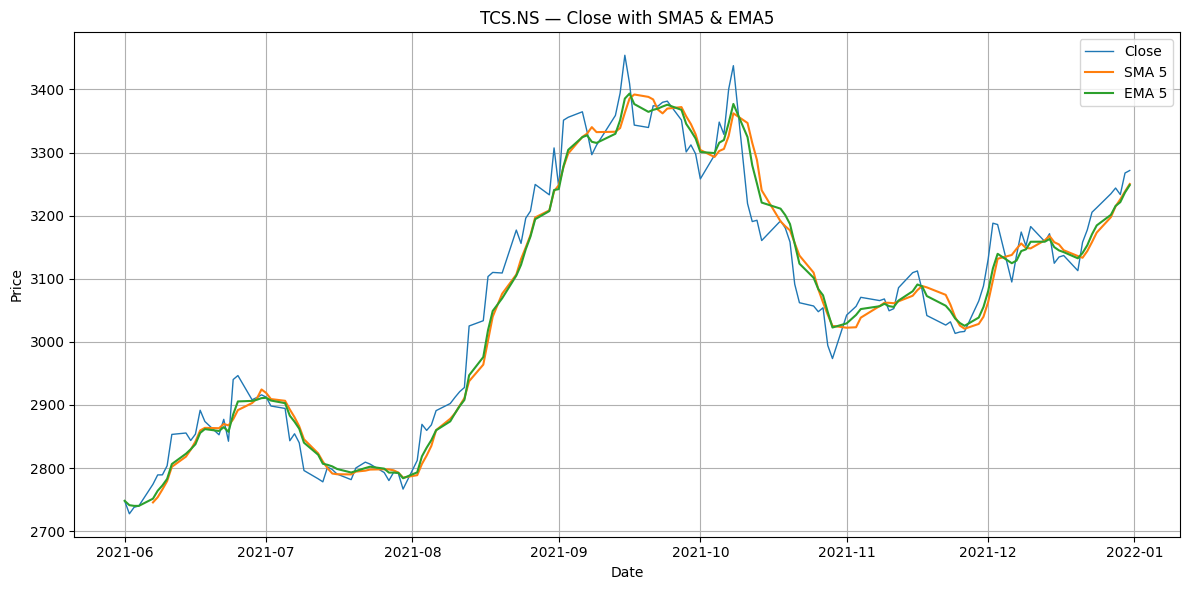

[*********************100%***********************]  1 of 1 completed


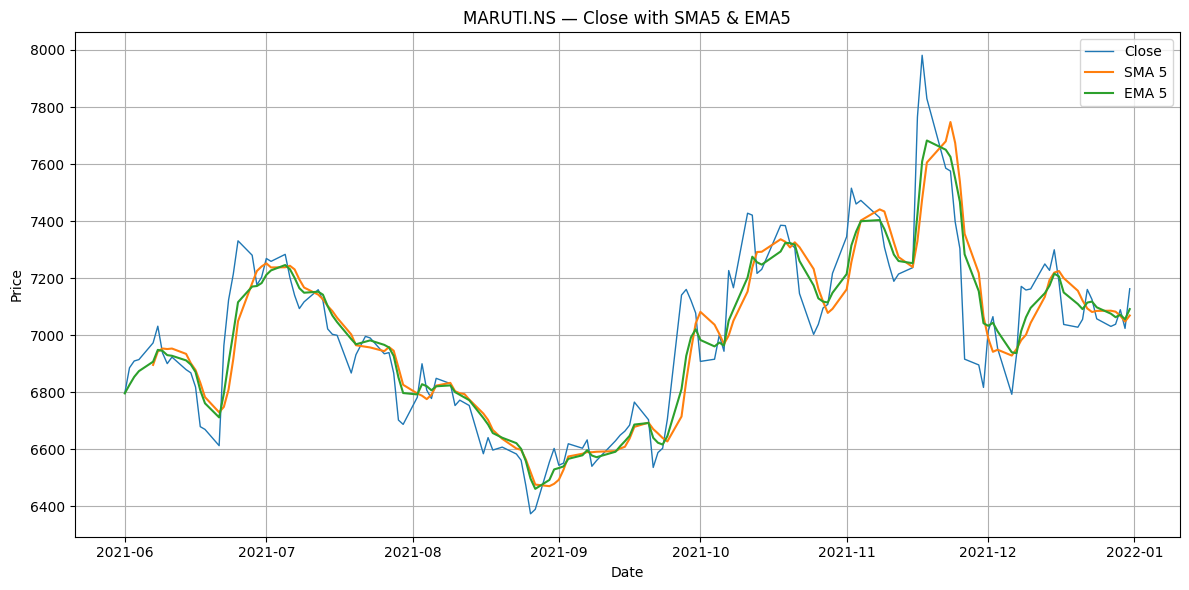

In [24]:
# Code here 
def plot_sma_ema_for_stocks(stocks, start='2021-06-01', end='2022-01-01', window=5):
    for ticker in stocks:
        df = yf.download(ticker, start=start, end=end, interval='1d')
        df['SMA_5'] = df['Close'].rolling(window=window).mean()
        df['EMA_5'] = df['Close'].ewm(span=window, adjust=False).mean()
        plt.figure(figsize=(12,6))
        plt.plot(df.index, df['Close'], label='Close', color='C0', linewidth=1)
        plt.plot(df.index, df['SMA_5'], label=f'SMA 5', color='C1', linewidth=1.5)
        plt.plot(df.index, df['EMA_5'], label=f'EMA 5', color='C2', linewidth=1.5)
        plt.title(f'{ticker} — Close with SMA5 & EMA5')
        plt.xlabel('Date'); plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


plot_sma_ema_for_stocks(['RELIANCE.NS', 'TCS.NS', 'MARUTI.NS'])

**MACD**  
   - Plot MACD and Signal line for each of the three stocks.
   - Fast Length (Short-term EMA): 12 periods
   - Slow Length (Long-term EMA): 26 periods
   - Signal Line (Smoothing EMA): 9 periods

    

[*********************100%***********************]  1 of 1 completed


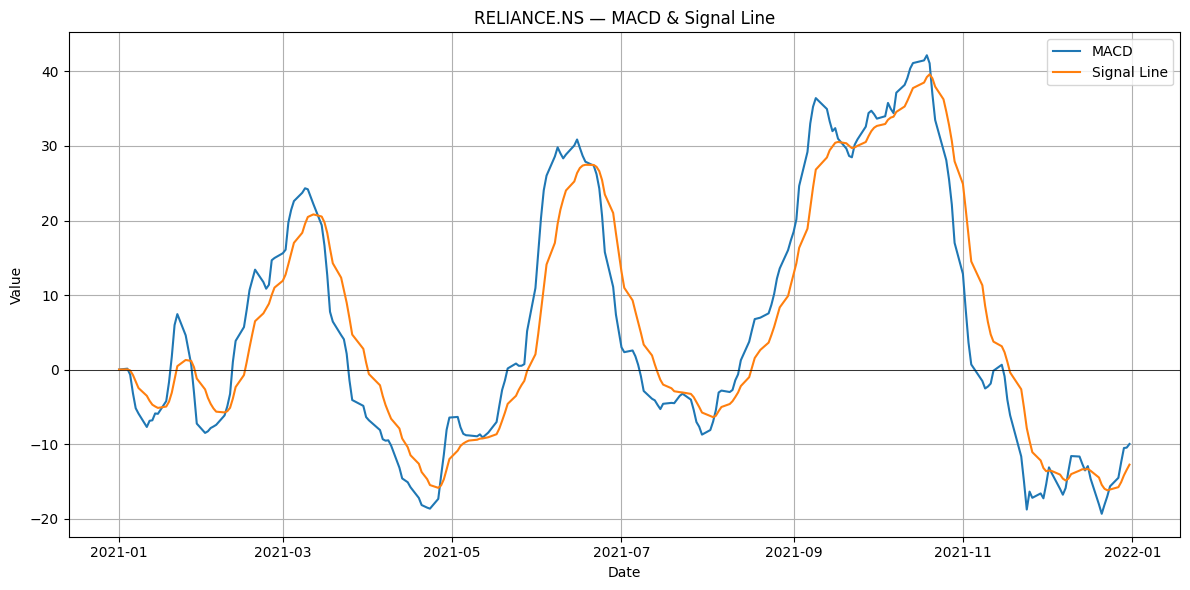

[*********************100%***********************]  1 of 1 completed


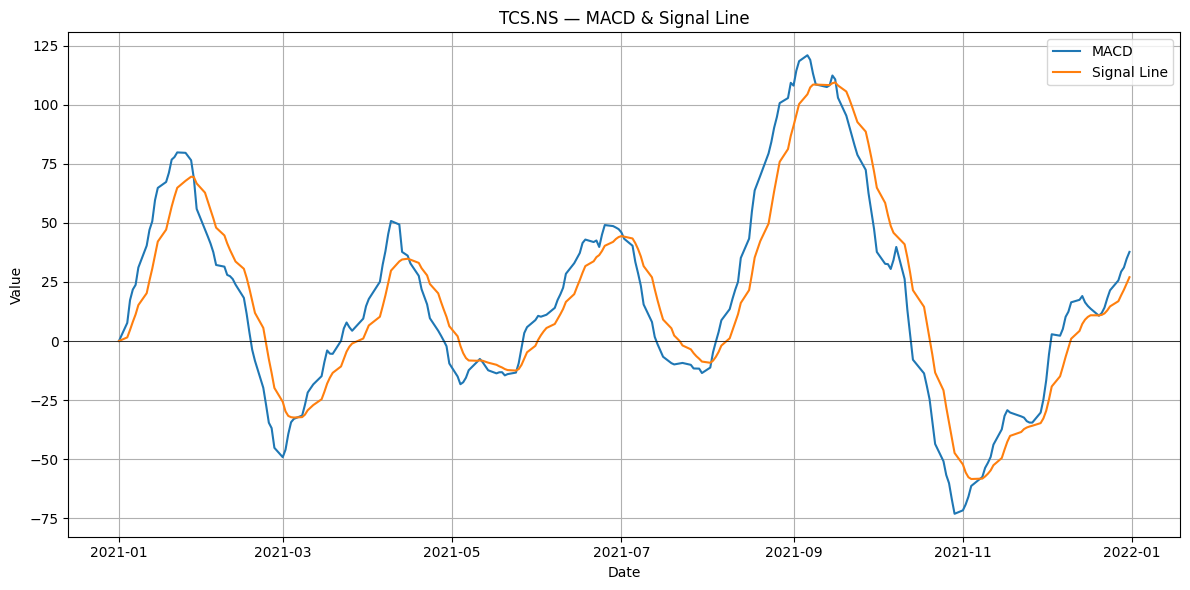

[*********************100%***********************]  1 of 1 completed


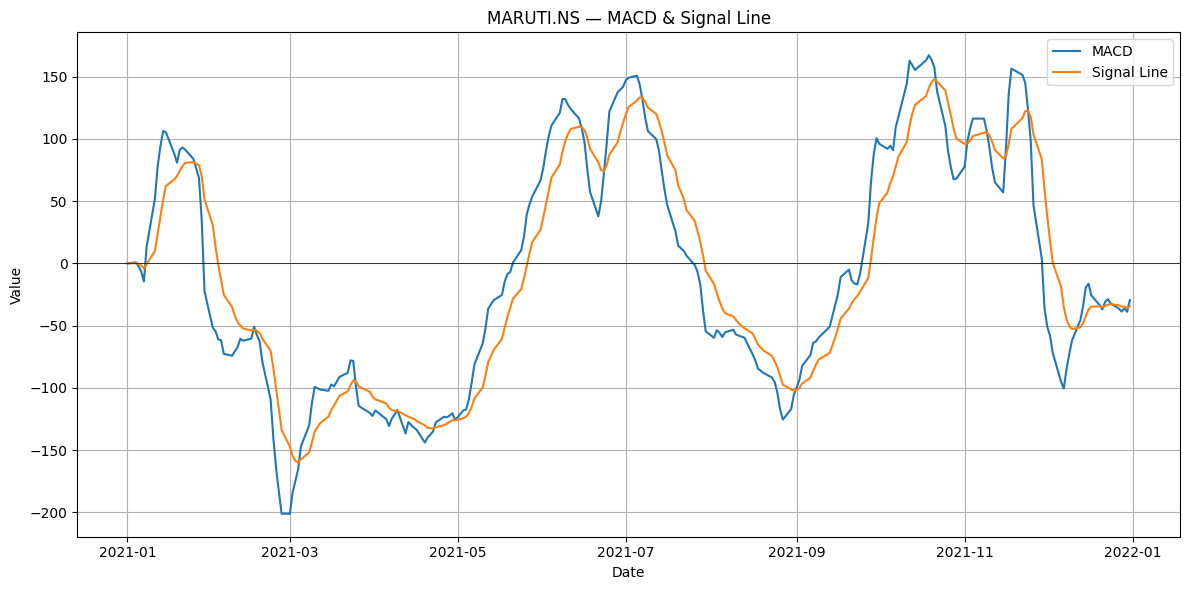

In [28]:
# Code Here
def macdstocks(stocks, start='2021-01-01', end='2022-01-01'):
    for ticker in stocks:
        df = yf.download(ticker, start=start, end=end, interval='1d')
        
        ema12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema12 - ema26
        df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

        plt.figure(figsize=(12, 6))
        plt.plot(df.index, df['MACD'], label='MACD', linewidth=1.5)
        plt.plot(df.index, df['Signal'], label='Signal Line', linewidth=1.5)
        plt.title(f'{ticker} — MACD & Signal Line')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.show()

macdstocks(['RELIANCE.NS', 'TCS.NS', 'MARUTI.NS'])

**RSI**  
   - Plot RSI for each of the three stocks
   - Period = 14 days 
   - Also show the overbought and oversold regions 
   - Overbought condition: RSI above 70
   - Oversold condition: RSI below 30
   
    

[*********************100%***********************]  1 of 1 completed


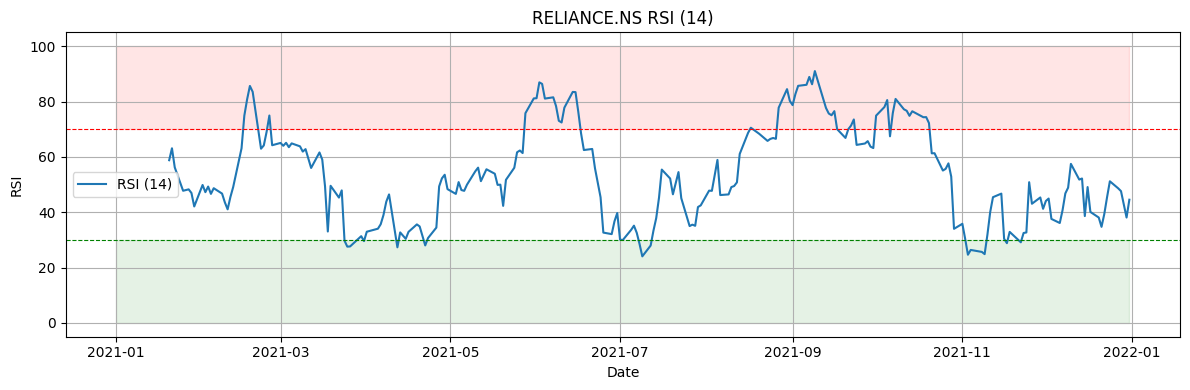

[*********************100%***********************]  1 of 1 completed


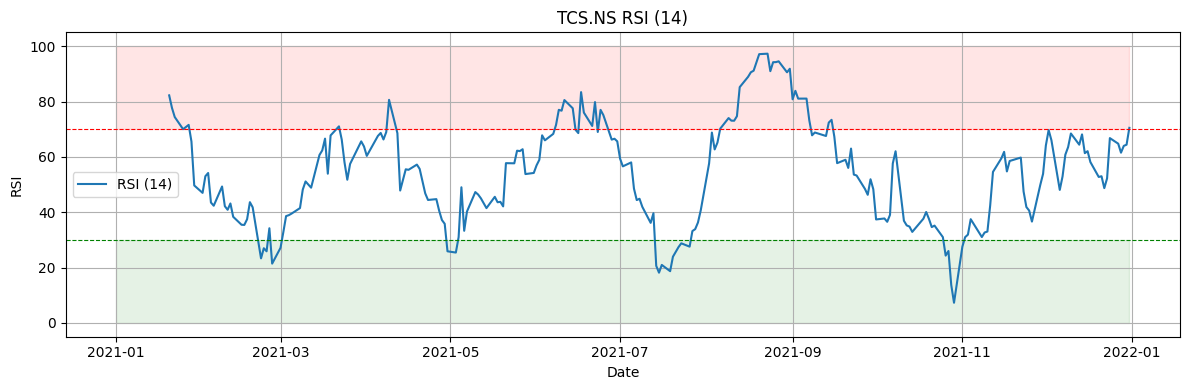

[*********************100%***********************]  1 of 1 completed


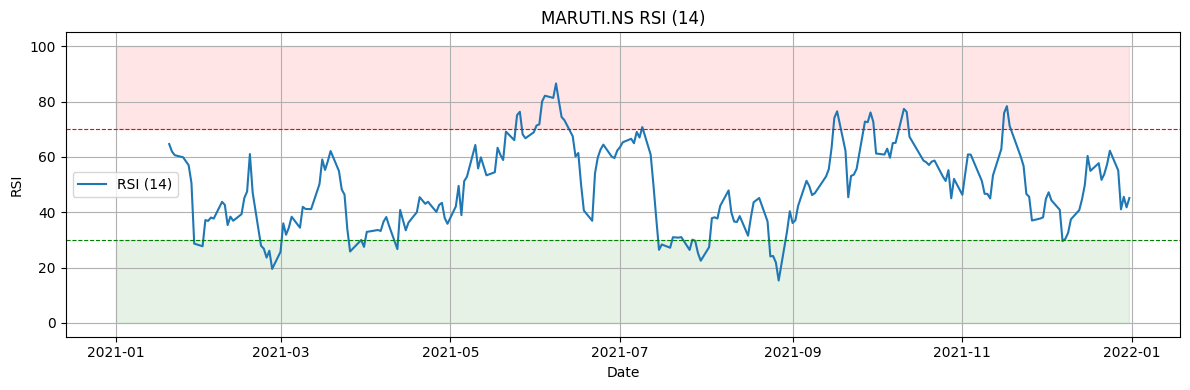

In [36]:
# Code here
def rsistocks(stocks, start='2021-01-01', end='2022-01-01', period=14):
    for ticker in stocks:
        df = yf.download(ticker, start=start, end=end, interval='1d')
        close = df['Close']
        delta = close.diff()

        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)

        avg_gain = gain.rolling(window=period).mean()
        avg_loss = loss.rolling(window=period).mean()

        rs = avg_gain / avg_loss

        rsi = 100 - (100 / (1 + rs))

        plt.figure(figsize=(12, 4))
        plt.plot(rsi.index, rsi, label=f'RSI ({period})', color='C0')
        plt.axhline(70, color='red', linestyle='--', linewidth=0.8)
        plt.axhline(30, color='green', linestyle='--', linewidth=0.8)
        plt.fill_between(rsi.index, 70, 100, color='red', alpha=0.1)
        plt.fill_between(rsi.index, 0, 30, color='green', alpha=0.1)
        plt.title(f'{ticker} RSI ({period})')
        plt.xlabel('Date')
        plt.ylabel('RSI')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

rsistocks(['RELIANCE.NS', 'TCS.NS', 'MARUTI.NS'])

### Summarize your analysis

In [ ]:
""" Write your answer here """